# TRAINING AND ASSESSING THE MODELS

For this notebook please make sure that in *./csv/datasets* there are the following files:
- csv/datasets/nifh_dataset.csv
- csv/datasets/nifh_dataset_simple_tr.csv
- csv/datasets/nifh_dataset_simple_tr_out.csv
- csv/datasets/nifh_dataset_scikit_0.csv
- csv/datasets/nifh_dataset_scikit_2.csv

## Libraries

In [310]:
import sys
print(sys.executable)

/usr/bin/python


In [311]:
#we import all they key libraries needed in this notebook
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib as matplotlib
import seaborn as sns
import joblib as joblib
from sklearn.metrics import mean_absolute_error

## Column names are stored 

In [312]:
x_columns = ['O2_knn', 'T_knn', 'N_knn', 'P_knn', 'Fe_knn', 'solar_knn']
y_columns =['Trichodesmium nifH Gene (x106 copies m-3)','UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)']

## Functions

In [313]:
def plotColsOnMap(cols,df, log_range = False, mult = 1):
    #the index is reset from using lat and lon just in case
    df_reset = df.reset_index()

    #the number of rows varies depending on the number of columns to plot
    rows = (len(cols)//2) + (len(cols)%2==1)

    #a set of subplots is created
    fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(20, rows*4), subplot_kw={"projection": ccrs.PlateCarree()})

    #we plot each column
    axes = axes.flatten()
    for i, col in enumerate(cols):
        ax = axes[i]#subplot

        #we want to see the coastlines on the globe and only take not null values
        ax.add_feature(cfeature.COASTLINE)
        valid_data = df_reset[df_reset[col].notna()]
        
        #this sets the logorithmic scale to be exactly like in the paper instead of default
        norm = matplotlib.colors.LogNorm(vmin=1e3, vmax=1e11)
        if(not log_range):
            norm = None

        #scatter plot is created
        sc = ax.scatter(
            valid_data["LONGITUDE"],
            valid_data["LATITUDE"],
            c=valid_data[col]*mult,
            cmap="viridis",
            s=40,
            transform=ccrs.PlateCarree(),
            norm=norm
        )

        #we want to see the entire globe and not just the values 
        ax.set_xlim(-180,180)
        ax.set_ylim(-90,90)

        label = "nifH Gene (copies m-3" if "nifH Gene (copies m-3)" in col else ""

        plt.colorbar(sc, ax=ax, label=label)
        ax.set_title(col.replace("x106 ",""))

    plt.tight_layout()
    plt.show()

In [314]:
def histCols(cols,df, log_range = False, transf = (lambda x: x), suptitle=""):
    #the index is reset from using lat and lon just in case
    df_reset = df.reset_index()

    #the number of rows varies depending on the number of columns to plot
    rows = (len(cols)//2) + (len(cols)%2==1)

    #a set of subplots is created
    fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(20, rows*4))

    #we plot each column
    axes = axes.flatten()
    for i, col in enumerate(cols):
        ax = axes[i]#subplot

        valid_data = df_reset[df_reset[col].notna()]
        transf(valid_data[col]).hist(bins=50, ax=ax)

        ax.set_title(col)

    
    if(len(suptitle)>0):
        plt.suptitle(suptitle, fontsize=16)

    plt.tight_layout()
    plt.show()

In [315]:
def getData(feature, dataset):
    return dataset.dropna(subset=feature, how='all')[x_columns+y_columns]

In order to make testing different models easier I created a function for that purpose. 

In [316]:
from sklearn.metrics import root_mean_squared_error

def train_model(model, X_train, y_train, model_name="-"):
    #we train the model
    model.fit(X_train, y_train)

    #get the preictions
    predictions = model.predict(X_train)

    error_rate = root_mean_squared_error(y_train, predictions)
    print("Model {0} achieved RMSE score of {1} on train dataset".format(model_name, error_rate))

    return error_rate

This is a simple model against which we can benchmark the results of other models and see if they perform better or not.

In [317]:
class DummyModel():
    value=None

    def __init__(self):
        self.value=None

    def fit(self, X_train, y_train):
        self.value = np.mean(y_train)

    def predict(self, X_train):
        return np.full(len(X_train), self.value)


## Loading transofrmers
In join_csv we created several transformers 

In [318]:
class SimpleTransformer():
    transforms = {
        "O2_knn":(lambda x: np.log(x*(10**6)+10)),
        "T_knn":(lambda x: np.log((x+10)*(10**6))),
        "N_knn":(lambda x: np.log(x*(10**3)+10)),
        "P_knn":(lambda x: np.log(x*(10**6)+10)),
        "Fe_knn":(lambda x: np.log(x*1000+10)),
        "solar_knn":(lambda x:x),
        'Trichodesmium nifH Gene (x106 copies m-3)':(lambda x: np.log(x*(10**6)+10)),
        'UCYN-A nifH Gene (x106 copies m-3)':(lambda x: np.log(x*(10**6)+10)),
        'UCYN-B nifH Gene (x106 copies m-3)':(lambda x: np.log(x*(10**10)+10))
    }

    inverse_transforms = {
        "O2_knn":(lambda x: (np.exp(x)-10)/(10**6)),
        "T_knn":(lambda x: (np.exp(x))/(10**6)-10),
        "N_knn":(lambda x: (np.exp(x)-10)/(10**3)),
        "P_knn":(lambda x: (np.exp(x)-10)/(10**6)),
        "Fe_knn":(lambda x: (np.exp(x)-10)/(10**3)),
        "solar_knn":(lambda x:x),
        'Trichodesmium nifH Gene (x106 copies m-3)':(lambda x: (np.exp(x)-10)/(10**6)),
        'UCYN-A nifH Gene (x106 copies m-3)':(lambda x: (np.exp(x)-10)/(10**6)),
        'UCYN-B nifH Gene (x106 copies m-3)':(lambda x: (np.exp(x)-10)/(10**10))
    }

    def __init__(self):
        print("simple transformer created")

    ''' 
    apply transformations to a set of columns based on a dictionary of the format:
    col_name --> lambda function on a numpy array
    '''
    def __applyTransormations(self, dct,df):
        new_df = pd.DataFrame()
        for key in dct.keys():
            new_df[key] = dct[key](df[key])
        return new_df
    
    ''' 
    forward transofrm before training
    '''
    def transform(self,df):
        print("applying the transform")
        return self.__applyTransormations(self.transforms, df)

    ''' 
    backward transform for the model results
    '''
    def inverse_transform(self,df):
        print("apply reverse")
        return self.__applyTransormations(self.reverse_transforms, df)


In [319]:
transformers = joblib.load("./model/transformers")

Apply inverse transformations if the data was transformed before training using scaler or mathematic formulas. Here it is important that the function always return a pandas dataframe with the column set identical to the original.

In [320]:
def transofrm_back(name,df):
    if "simple_transformer" in name:
        return SimpleTransformer().inverse_transform(df)
    elif "0" in name:
        transfored_arr = transformers["scikit scaler 0"].inverse_transform(df)
    elif "1" in name:
        transfored_arr = transformers["scikit scaler 1"].inverse_transform(df)
    else:
        return df
    
    return pd.DataFrame(transfored_arr, columns=df.columns)


A model is scored on the training and test data while transforming it to the original scale in order to see how off from the actual value we land.

In [321]:
def score_model(model, data_x, data_y, dataset_name, feature):
    #we predict using the model
    predictions = model.predict(data_x)
    predictions_df = data_x.copy()
    #we need to also have the original value
    score_df = pd.concat([data_x.copy(),data_y.copy()],axis=1)

    #for inverse transform to work the scalers in sci kit learn require the columns to be in the same order
    #as when fit was applied and be the same list
    for col in y_columns:
        if col == feature:
            predictions_df[feature] = predictions
        else:
            predictions_df[col]=data_y[col]            

    #after we format the data inverse transform can be applied. 
    tr_pr = transofrm_back(name=dataset_name, df=predictions_df)[feature]
    tr_sc = transofrm_back(name=dataset_name, df=score_df)[feature]

    print("absolute error: {0}".format(mean_absolute_error(tr_sc, tr_pr)))
    return mean_absolute_error(tr_sc, tr_pr)
    

## Loading the datasets

We need to load the data into the notebook and store it in a dictionary

In [322]:
#this is how paths are stored and the names persist in the code
paths = {
    "raw_data": "./csv/datasets/nifh_dataset.csv",
    "simple_transform": "./csv/datasets/nifh_dataset_simple_tr.csv",
    "simple_transform without 'outliers'":"./csv/datasets/nifh_dataset_simple_tr_out.csv",
    "scikit scaler 0": "./csv/datasets/nifh_dataset_scikit_0.csv",
    "scikit scaler 2": "./csv/datasets/nifh_dataset_scikit_2.csv"
}

#here we store the pandas dataframes before splitting
datasets = dict()

#we open and store the csv files
for name, path in paths.items():
    datasets[name] = pd.read_csv(path)[x_columns+y_columns]

In [323]:
for name, dataset in datasets.items():
    print("DATASET: {0}".format(name))
    print(dataset.info())

DATASET: raw_data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1166 entries, 0 to 1165
Data columns (total 9 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   O2_knn                                     1166 non-null   float64
 1   T_knn                                      1166 non-null   float64
 2   N_knn                                      1166 non-null   float64
 3   P_knn                                      1166 non-null   float64
 4   Fe_knn                                     1166 non-null   float64
 5   solar_knn                                  1166 non-null   float64
 6   Trichodesmium nifH Gene (x106 copies m-3)  963 non-null    float64
 7   UCYN-A nifH Gene (x106 copies m-3)         973 non-null    float64
 8   UCYN-B nifH Gene (x106 copies m-3)         632 non-null    float64
dtypes: float64(9)
memory usage: 82.1 KB
None
DATASET: simple_transform
<class 'pand

## Displaying data
I want to show the initial distributions as it can be useful when interpreting results.

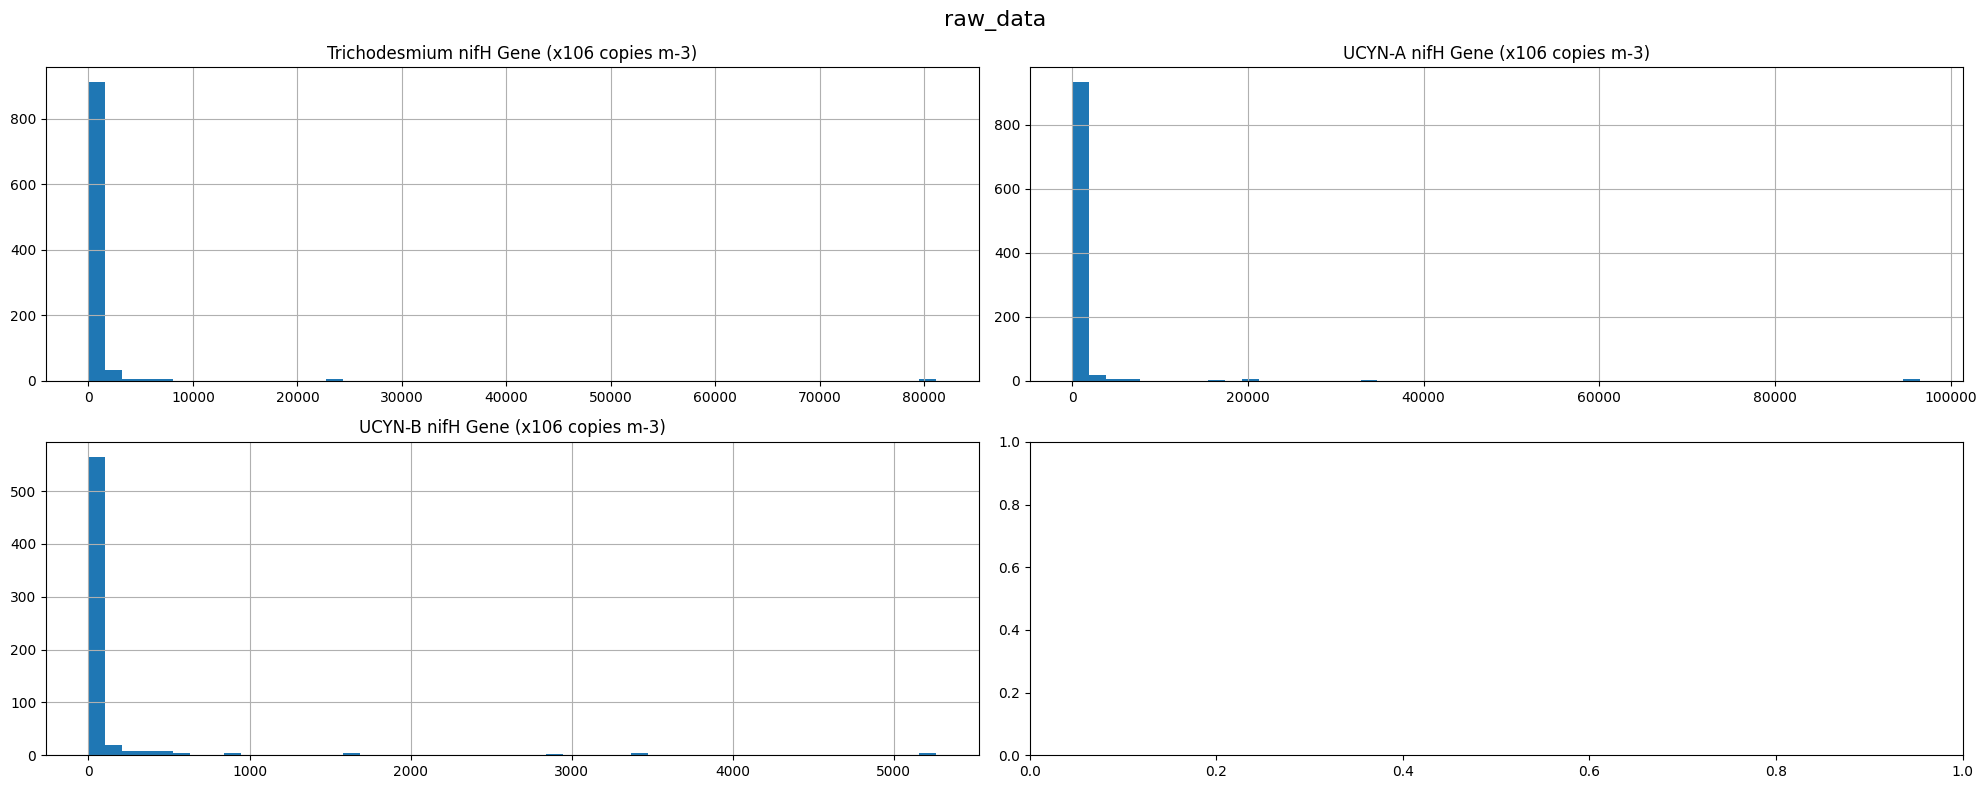

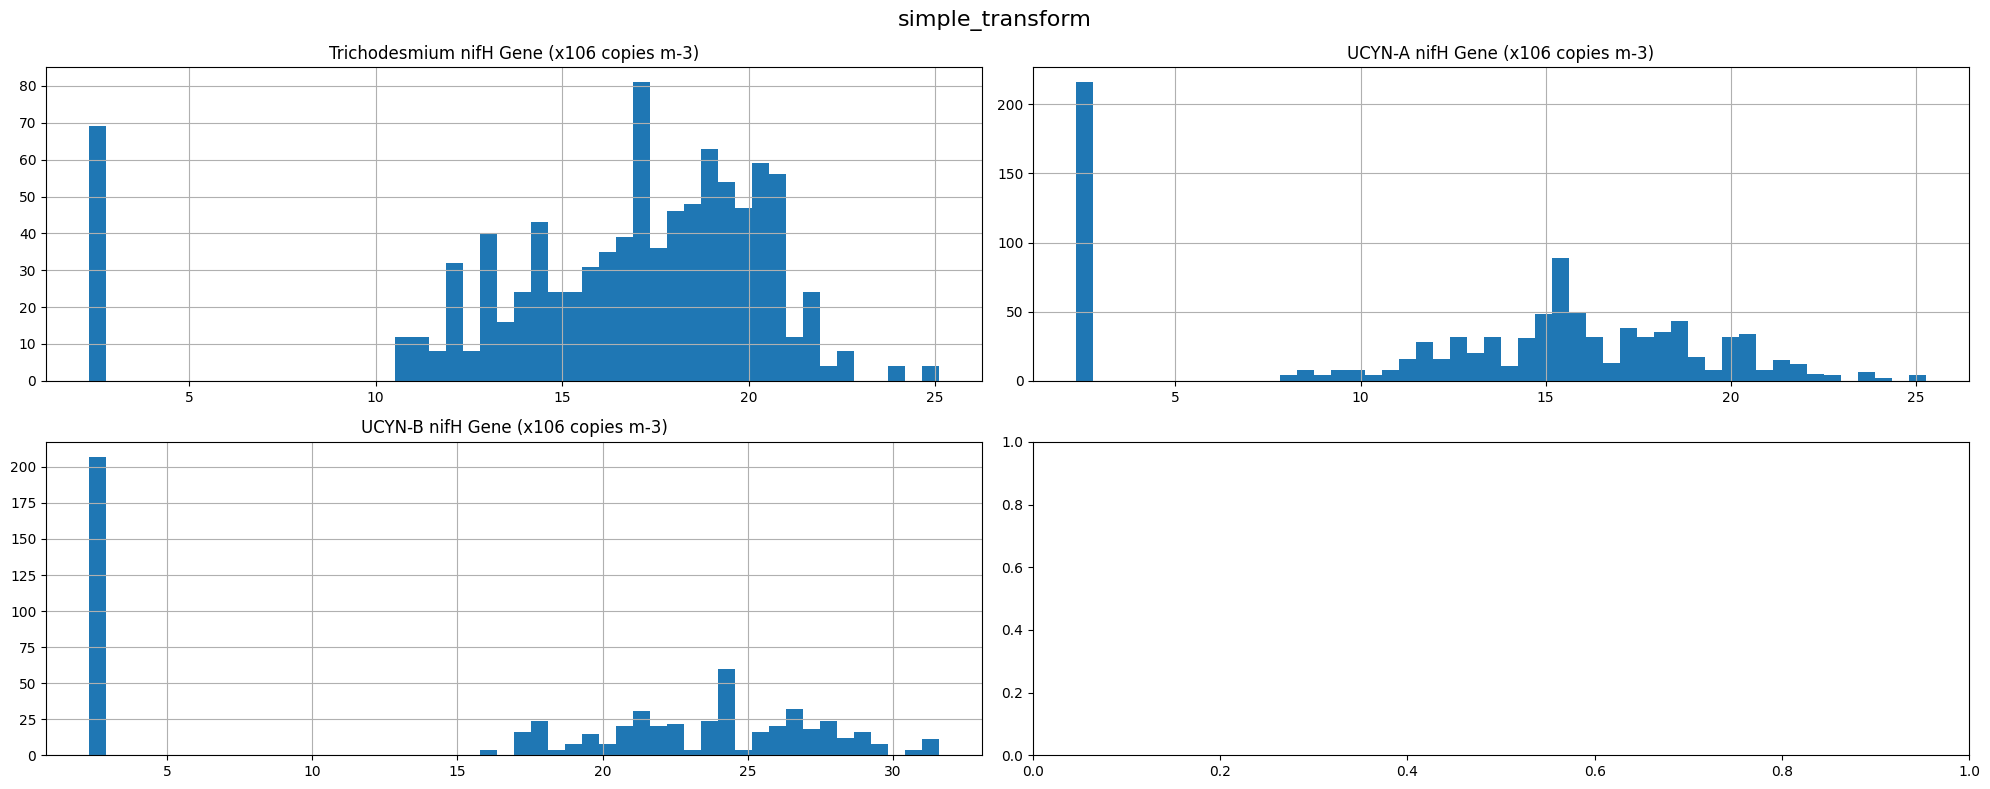

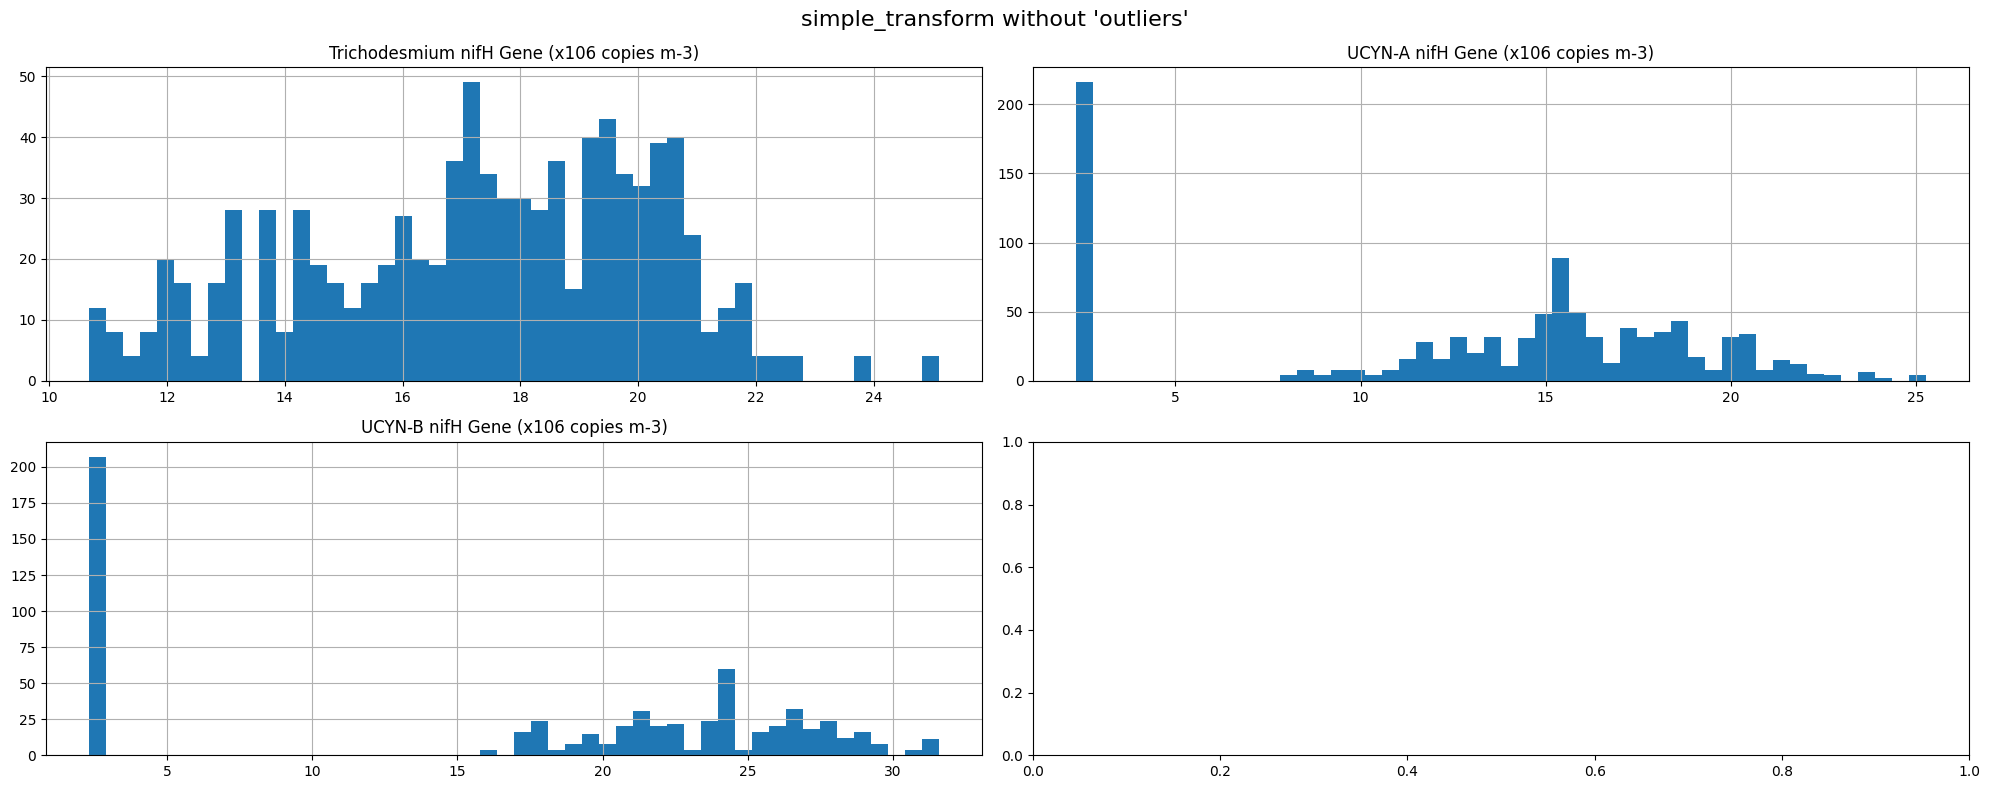

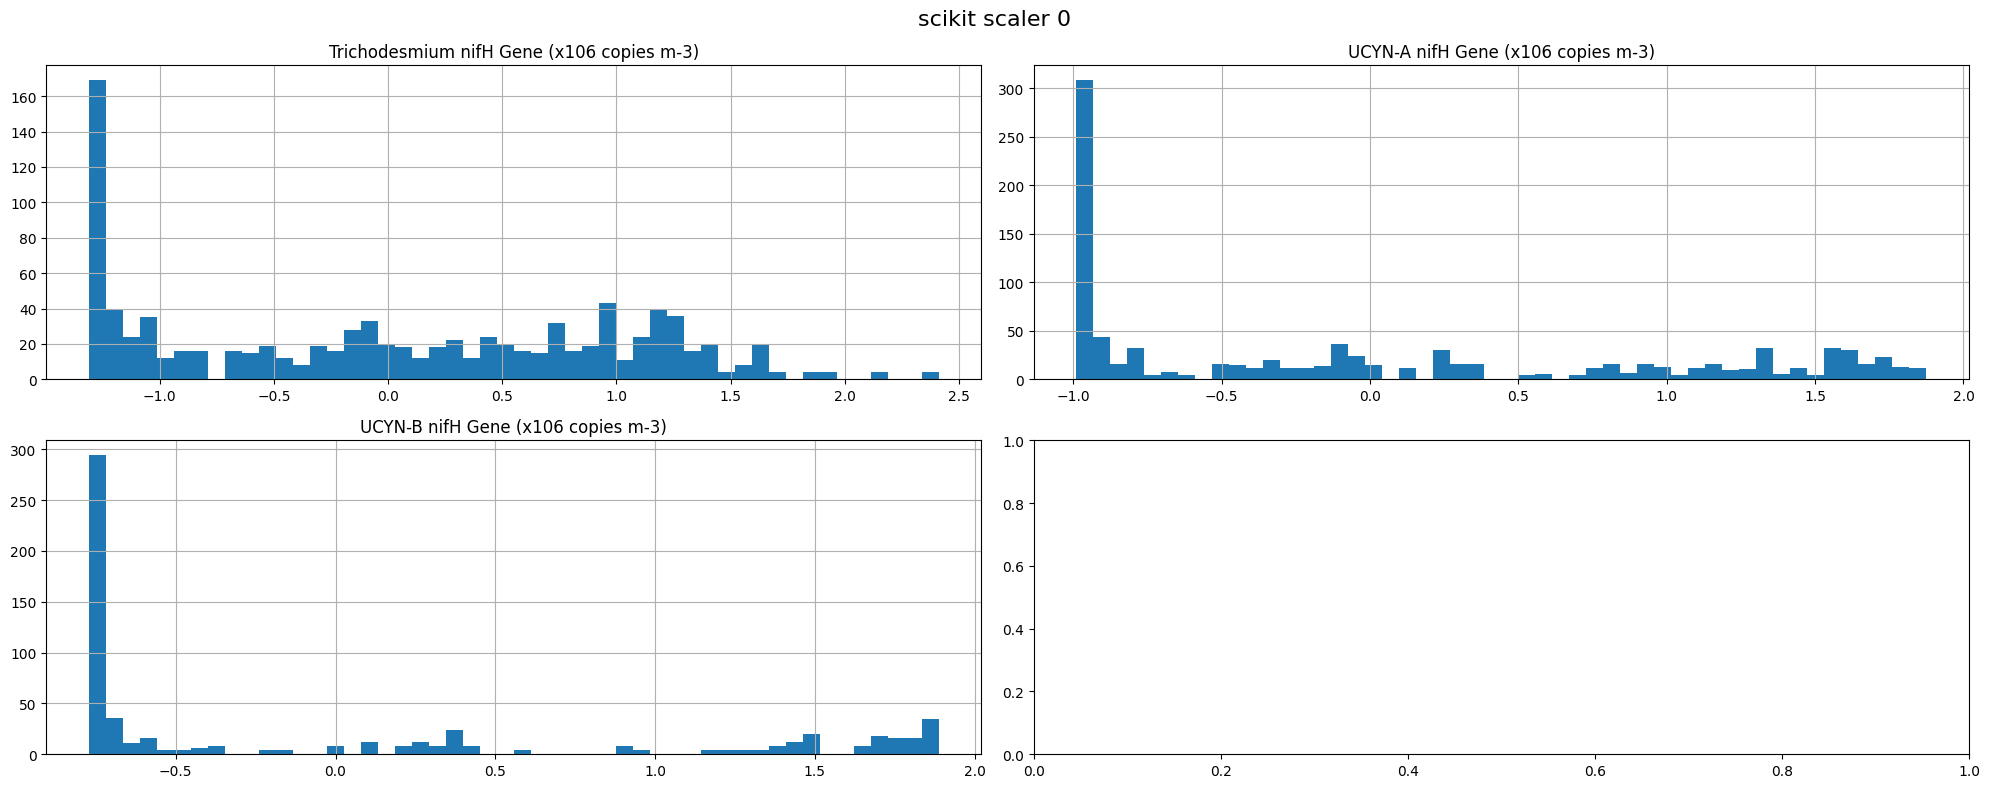

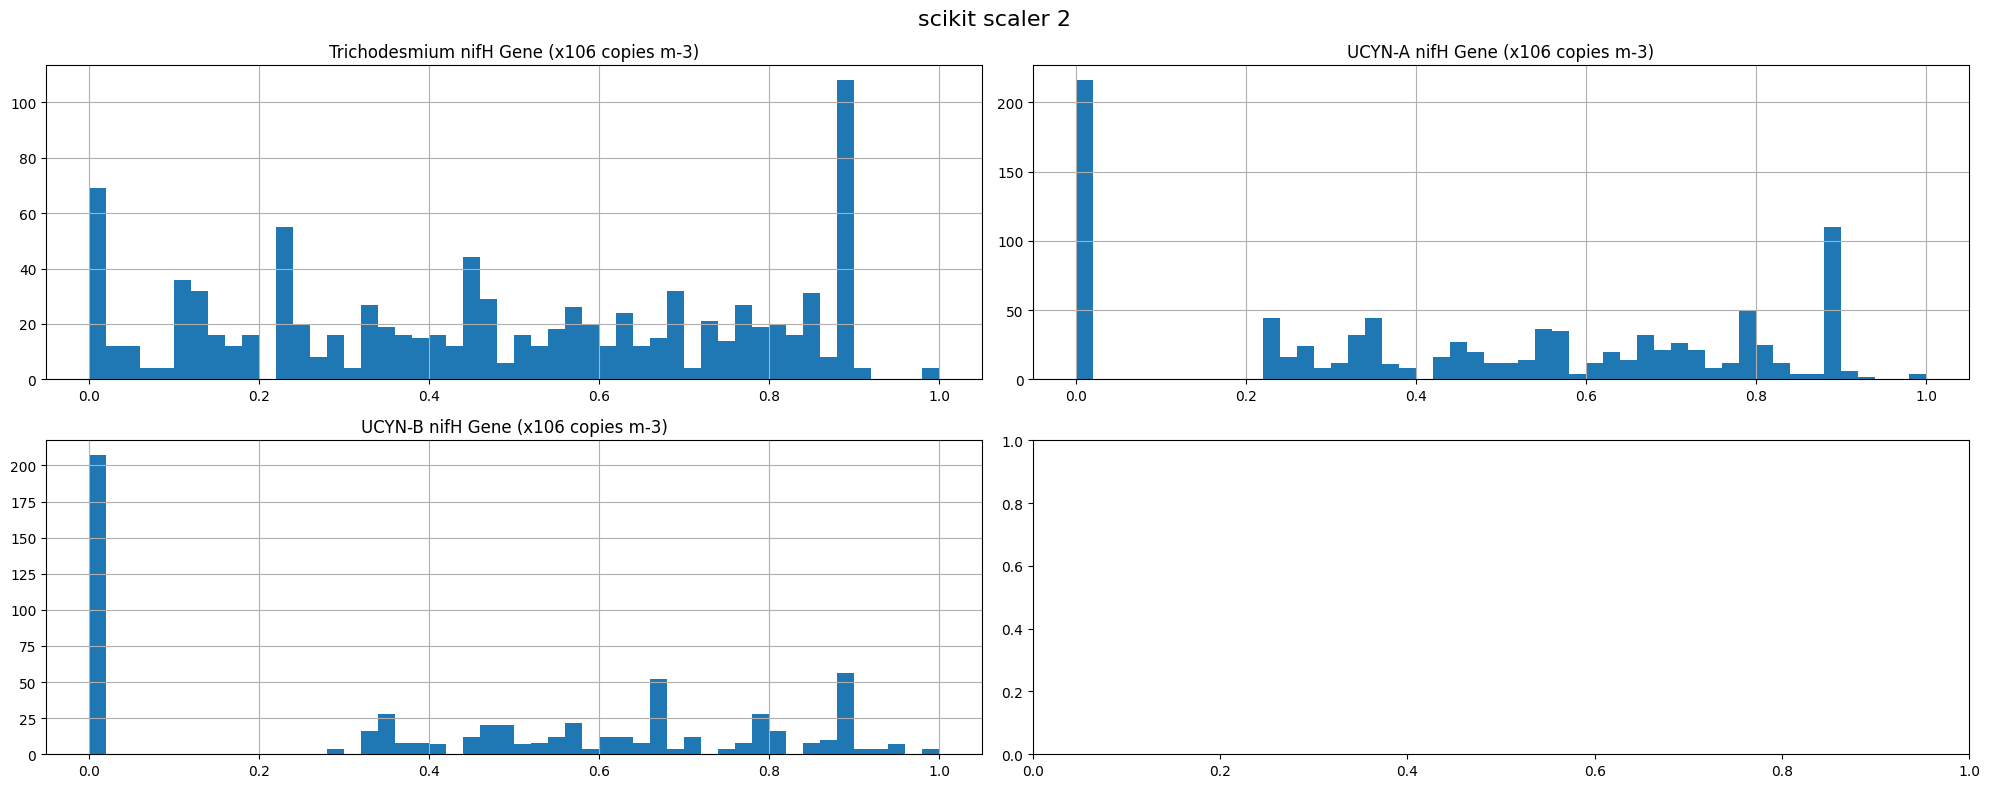

In [324]:
for name, dataset in datasets.items():
    histCols(y_columns, dataset, suptitle=name)

## Train test split

In order to verify that the data is actually generalizable and that the model can preditct on data it has never seen before we need to test it on such data that we set aside before training.

The data structure is the following:

```
training data:
{                                                         
    "name": {                                        
        "feature":{X_train, X_test, y_train, y_test}    
        "feature1":{X_train, X_test, y_train, y_test}   
        "feature2":{X_train, X_test, y_train, y_test}   
    }                                                   
    "name2": {                                          
        ...                                             
    }                                                      
}                                                       
```

In [325]:
from sklearn.model_selection import train_test_split

training_data = dict()

for name, dataset in datasets.items():
    training_data[name]=dict()
    for feature in y_columns:
        #we filter the data by the feature before splitting
        temp_ds = getData([feature], dataset)
        X_train, X_test, y_train, y_test = train_test_split(temp_ds[x_columns], temp_ds[y_columns], test_size=0.2, random_state=42)

        #we store the split data
        temp_dict = {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test
        }

        #add results to the dictionary
        training_data[name][feature] = temp_dict

## Storing test results
In order to compare, store and visualize testing results we need a pandas dataframe

In [326]:
test_scores = pd.DataFrame(columns=["dataset name", "feature", "model", "train_rsme_score","train_abs_score","test_abs_score"])

## Functions for testing different models

Training a given model on all datasets and storing the results in a common dataframe.

In [327]:
def try_model_on_all(model, model_name):
    for name in paths.keys():
        print("DATASET TEST: {0}".format(name))
        for feature in y_columns:
            print("FEATURE: {0}")
            data = training_data[name][feature]
            X_train = data["X_train"]
            y_train = data["y_train"][feature]

            #model is trained
            train_rsme_score = train_model(model, X_train=X_train, y_train=y_train, model_name=model_name)

            print("training data:")
            train_abs_score = score_model(model, X_train, data["y_train"], name, feature)

            print("test data:")
            test_abs_score = score_model(model, data["X_test"], data["y_test"], name, feature)

            print("")
            ## we save the final results:
            test_scores.loc[test_scores.shape[0]]=[name, feature, model_name, train_rsme_score, train_abs_score, test_abs_score]

        print("")

## Training a baseline model

For a good baseline we can consider using linear regression and just taking the mean. Likely neither will be great, but that is the point. We want to see that better more suited models can achieve higher results.

In [328]:
model = DummyModel()
model_name ="dummy model"

try_model_on_all(model, model_name)

DATASET TEST: raw_data
FEATURE: {0}
Model dummy model achieved RMSE score of 6078.037656839828 on train dataset
training data:
absolute error: 1329.284793133678
test data:
absolute error: 770.9934506000764

FEATURE: {0}
Model dummy model achieved RMSE score of 6310.283268263187 on train dataset
training data:
absolute error: 1235.2973707769322
test data:
absolute error: 1538.6135372448796

FEATURE: {0}
Model dummy model achieved RMSE score of 597.5153498432949 on train dataset
training data:
absolute error: 208.61978133451416
test data:
absolute error: 158.72637495898607


DATASET TEST: simple_transform
FEATURE: {0}
Model dummy model achieved RMSE score of 4.8349482524401255 on train dataset
training data:
absolute error: 3.474302062353969
test data:
absolute error: 3.371770555624211

FEATURE: {0}
Model dummy model achieved RMSE score of 6.504462978737 on train dataset
training data:
absolute error: 5.3933256819084265
test data:
absolute error: 4.9820821142039655

FEATURE: {0}
Model du

## Trying out more models

In [329]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model_name="Linear regression"

try_model_on_all(model, model_name)

DATASET TEST: raw_data
FEATURE: {0}
Model Linear regression achieved RMSE score of 6036.277870614617 on train dataset
training data:
absolute error: 1434.1937102714232
test data:
absolute error: 883.8037616020708

FEATURE: {0}
Model Linear regression achieved RMSE score of 6243.589578833627 on train dataset
training data:
absolute error: 1469.6485635567499
test data:
absolute error: 1710.1180074874126

FEATURE: {0}
Model Linear regression achieved RMSE score of 574.7945043334265 on train dataset
training data:
absolute error: 224.13105789916474
test data:
absolute error: 174.7118718255913


DATASET TEST: simple_transform
FEATURE: {0}
Model Linear regression achieved RMSE score of 4.653299615445691 on train dataset
training data:
absolute error: 3.342338819672185
test data:
absolute error: 3.2441206471463704

FEATURE: {0}
Model Linear regression achieved RMSE score of 6.069866622882167 on train dataset
training data:
absolute error: 4.931482639412938
test data:
absolute error: 4.7005506

In [330]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model_name="Random forest regressor"
try_model_on_all(model, model_name)

DATASET TEST: raw_data
FEATURE: {0}
Model Random forest regressor achieved RMSE score of 2281.8649195805842 on train dataset
training data:
absolute error: 377.5721680573318
test data:
absolute error: 685.5260817672378

FEATURE: {0}
Model Random forest regressor achieved RMSE score of 2391.9828655802544 on train dataset
training data:
absolute error: 392.5366637351014
test data:
absolute error: 1850.6288785478523

FEATURE: {0}
Model Random forest regressor achieved RMSE score of 188.8606289883865 on train dataset
training data:
absolute error: 50.75491954099027
test data:
absolute error: 140.56555287650005


DATASET TEST: simple_transform
FEATURE: {0}
Model Random forest regressor achieved RMSE score of 1.0064277955774619 on train dataset
training data:
absolute error: 0.6970560493661829
test data:
absolute error: 1.85557405770935

FEATURE: {0}
Model Random forest regressor achieved RMSE score of 1.365385039942292 on train dataset
training data:
absolute error: 0.9520936725119843
test 

## Visualizing the results

In [331]:
test_scores.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45 entries, 0 to 44
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   dataset name      45 non-null     object 
 1   feature           45 non-null     object 
 2   model             45 non-null     object 
 3   train_rsme_score  45 non-null     float64
 4   train_abs_score   45 non-null     float64
 5   test_abs_score    45 non-null     float64
dtypes: float64(3), object(3)
memory usage: 2.5+ KB


In [332]:
test_scores.head()

,dataset name,feature,model,train_rsme_score,train_abs_score,test_abs_score
0,raw_data,Trichodesmium nifH Gene (x106 copies m-3),dummy model,6078.037657,1329.284793,770.993451
1,raw_data,UCYN-A nifH Gene (x106 copies m-3),dummy model,6310.283268,1235.297371,1538.613537
2,raw_data,UCYN-B nifH Gene (x106 copies m-3),dummy model,597.515350,208.619781,158.726375
3,simple_transform,Trichodesmium nifH Gene (x106 copies m-3),dummy model,4.834948,3.474302,3.371771
4,simple_transform,UCYN-A nifH Gene (x106 copies m-3),dummy model,6.504463,5.393326,4.982082


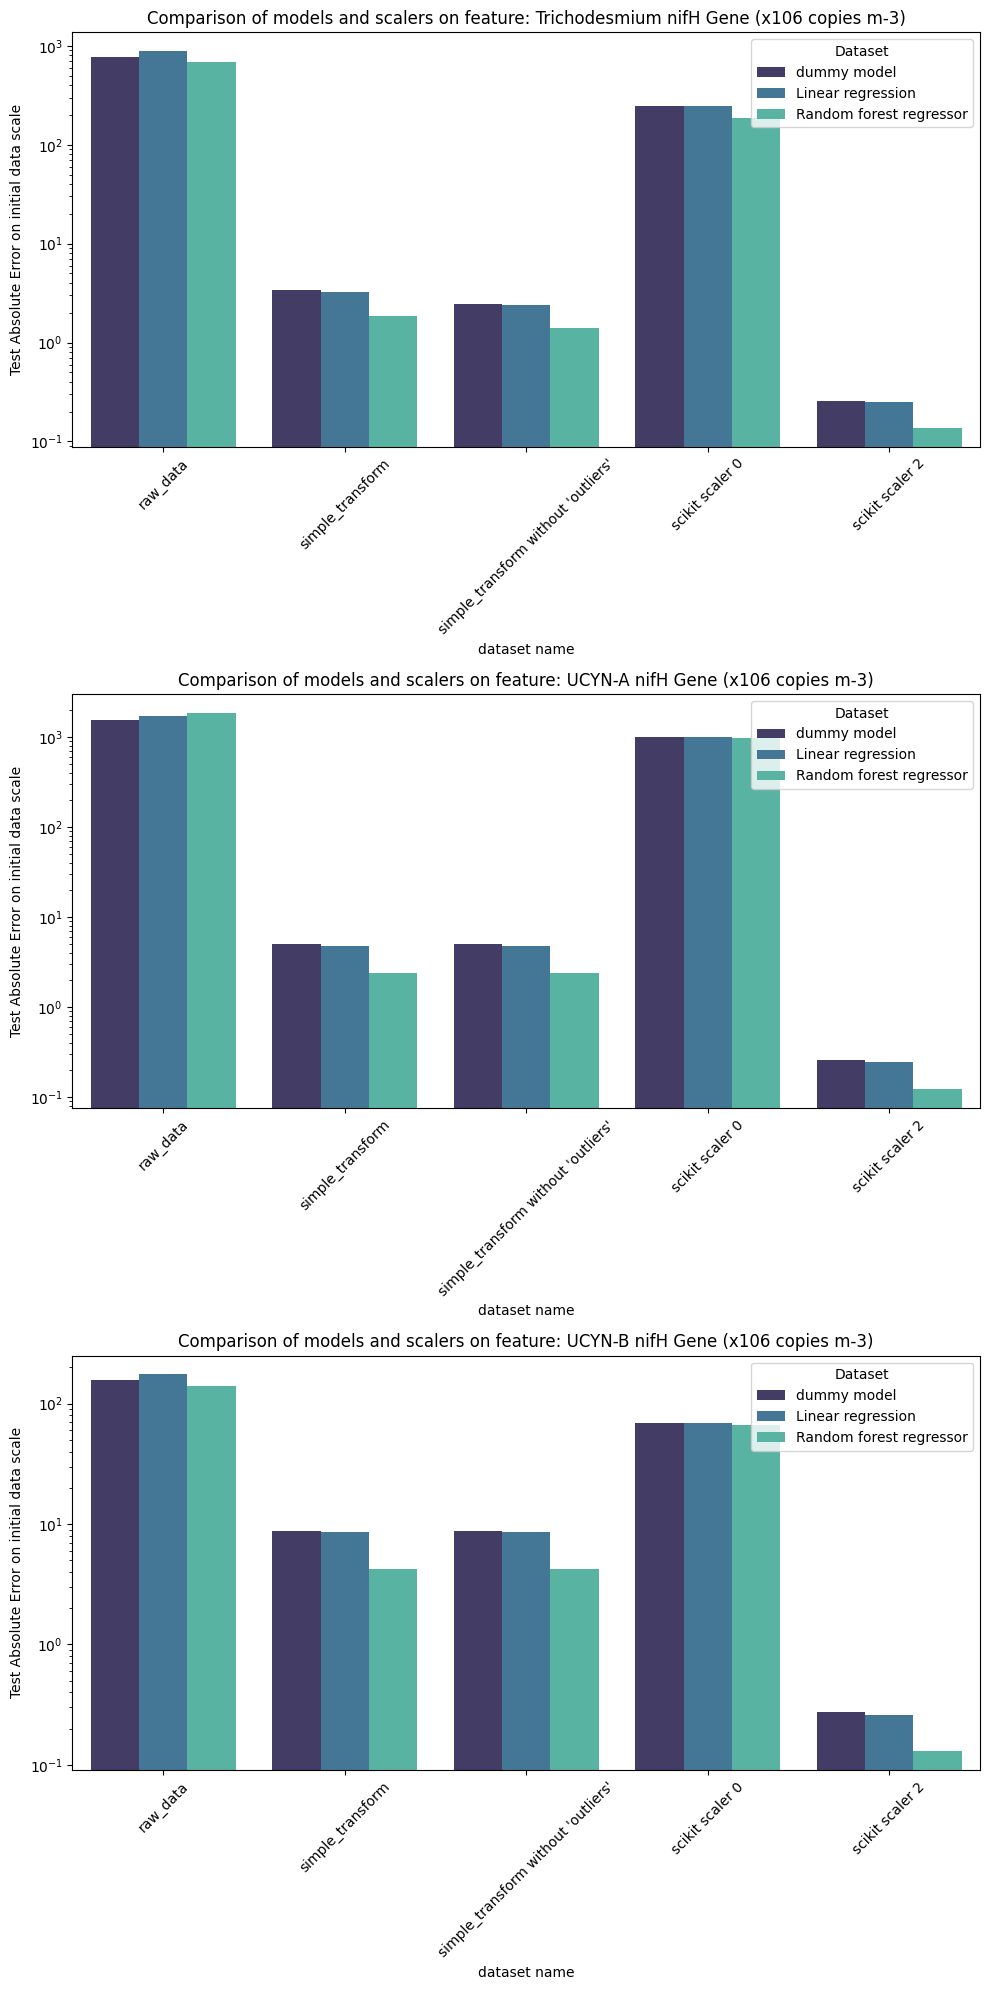

In [333]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 20))
axes = axes.flatten()

for i, feature in enumerate(y_columns):
    ax=axes[i]
    
    ##we plot a single feature
    subset = test_scores[test_scores['feature'] == feature]

    sns.barplot(
        data=subset,
        x='dataset name',
        y='test_abs_score',
        hue='model',
        palette='mako',
        ax=ax
    )

    ax.set_title('Comparison of models and scalers on feature: {0}'.format(feature))
    ax.set_ylabel('Test Absolute Error on initial data scale')
    ax.set_yscale('log')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Dataset')
plt.tight_layout()
plt.show()